In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import seaborn as sns; sns.set_theme(style='ticks', context='paper')

from SALib.sample import sobol
from SALib.analyze.sobol import analyze

In [2]:
#One step second order reversible action : A + B <--> C
#IN A PFR

#With fixed k1/km1

k1 = 20 # M-1 min-1
km1 = 0.01 #min-1
#Initial oscillations
A0_ss = 0.001 #mol/L
B0_ss = 0.0004 # mol/L - For 2nd order reactions
TAU = 30 #minutes - Residence time
PERIOD = 120 #min
kf = 1/TAU # = flowrate (µL/min)/Reactor volume (µL) = 1/residence time (min)

def d1_2nd_rev_dt(x, t, *args):
    A,B,C = x
    k1, km1 = args
    dAdt = -k1 * A * B + km1 * C
    dBdt = -k1 * A * B + km1 * C
    dCdt = k1 * A * B - km1 * C
    return dAdt, dBdt, dCdt


In [3]:
def PFR_ODE(d1_2nd_rev_dt, t, args=(k1,km1)):
    out_df = pd.DataFrame()
    A0 = A0_ss*(1 + np.sin(2*np.pi*t/PERIOD))
    A = []
    B = []
    C = []
    for value in A0:
        x0 = value, 0.0004, 0 #initial conditions
        sol = odeint(d1_2nd_rev_dt, x0, t, args=(k1,km1))
        A_out = sol[30,0] # Solution after 30 min
        B_out = sol[30,1]
        C_out = sol[30,2]
        A.append(A_out)
        B.append(B_out)
        C.append(C_out)
    return A, B, C

### Second order reversible reaction

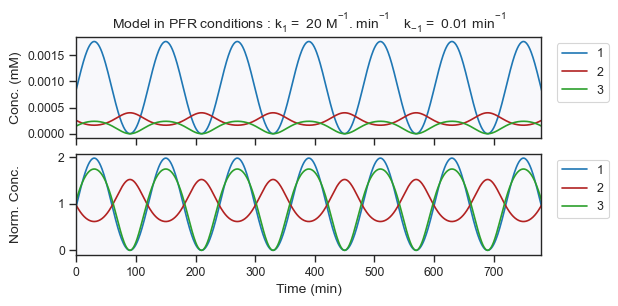

In [5]:
#One step reaction : A + B --> C


t = np.linspace(0, 1000, 1001)
#x0 = 0.001, 0.0004, 0 #initial conditions
A, B, C = PFR_ODE(d1_2nd_rev_dt, t, args=(k1,km1))

A_overlay = A / (sum(A) / len(A))
B_overlay = B / (sum(B) / len(B))
C_overlay = C / (sum(C) / len(C))

fig, ax = plt.subplots(2,1, figsize=(6, 2))

params = {'mathtext.default': 'regular' }          
plt.rcParams.update(params)

sns.lineplot(x = t, y = A_overlay, ax=ax[1], c='tab:blue', label='1')
sns.lineplot(x = t, y = B_overlay, ax=ax[1], c='firebrick', label='2')
sns.lineplot(x = t, y = C_overlay, ax=ax[1], c='tab:green', label='3')
sns.lineplot(x = t, y = A, ax=ax[0], c='tab:blue', label='1')
sns.lineplot(x = t, y = B, ax=ax[0], c='firebrick', label='2')
sns.lineplot(x = t, y = C, ax=ax[0], c='tab:green', label='3')

#ax[0].set_ylim(0,0.002)
#ax[1].set_ylim(0,2)
ax[0].set_xlim(0,780)
ax[1].set_xlim(0,780)


ax[0].set_ylabel("Conc. (mM)", fontsize = 10)
ax[1].set_ylabel("Norm. Conc.", fontsize = 10)
ax[0].set_xlabel("")
ax[1].set_xlabel("Time (min)", fontsize = 10)

ax[0].set_xticklabels("")
fig.align_ylabels(ax[:])

ax[0].legend(bbox_to_anchor=(1.02, 1.0), loc='upper left', fontsize = 9)
ax[1].legend(bbox_to_anchor=(1.02, 1.0), loc='upper left', fontsize = 9)

ax[0].set_facecolor('#F8F8FB')
ax[1].set_facecolor('#F8F8FB')

ax[0].set_title('Model in PFR conditions : $k_{1} =\ 20 \ M^{-1}.min^{-1} \quad k_{-1} =\ 0.01 \ min^{-1}$', fontsize = 10)

plt.subplots_adjust(left=None, bottom=None, right=None, top=1.2, wspace=None, hspace=0.15)
#plt.savefig('Figure2_model_PFR.svg', format='svg', bbox_inches='tight', dpi=600)